In [34]:
import random
from typing import NotRequired, TypedDict

from langgraph.graph import END, START, StateGraph
from pydantic import BaseModel, Field


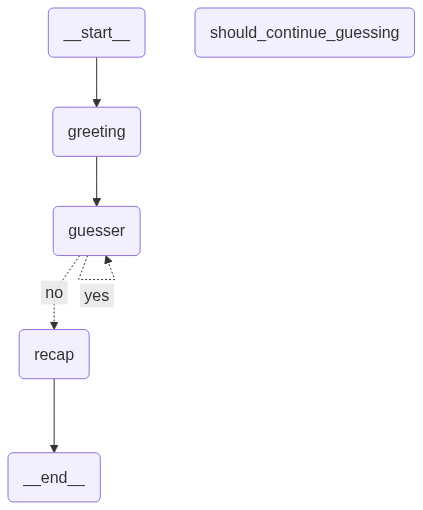

In [38]:
class AgentState(BaseModel):
    name: str
    answer: int

    curr_attempt: int = 0
    max_attempts: int

    lower_bound: int
    upper_bound: int

    guesses: list[int] = Field(default_factory=list)
    did_guess_correctly: bool = False
    result: str = ""


def greeting_node(state: AgentState) -> AgentState:
    state.guesses = []
    state.curr_attempt = 0
    state.did_guess_correctly = False
    state.result = (
        f"Hello {state.name}, lets try to guess your secret number :D\n"
    )
    return state


def guesser_node(state: AgentState) -> AgentState:
    rand_num = random.randint(state.lower_bound, state.upper_bound)
    state.guesses.append(rand_num)
    state.did_guess_correctly = rand_num == state.answer
    state.curr_attempt += 1
    return state


def should_continue_guessing(state: AgentState) -> str:
    if state.did_guess_correctly or state.curr_attempt >= state.max_attempts:
        return "no"
    else:
        return "yes"


def recap_node(state: AgentState) -> AgentState:
    if state.did_guess_correctly:
        state.result += "It looks like we got it :)"
    else:
        state.result += "Welp.. i ran out of attempts, you won :p"

    guesses_joined = ", ".join(map(str, state.guesses))
    state.result += f"\nGuesses we ran: {guesses_joined}"

    return state


graph = StateGraph(AgentState)
graph.add_node("greeting", greeting_node)
graph.add_node("guesser", guesser_node)
graph.add_node("should_continue_guessing", lambda state: state)
graph.add_node("recap", recap_node)

graph.add_edge(START, "greeting")
graph.add_edge("greeting", "guesser")
graph.add_conditional_edges(
    "guesser",
    should_continue_guessing,
    {
        "no": "recap",
        "yes": "guesser",
    },
)

graph.add_edge("recap", END)

app = graph.compile()
app

In [40]:
result = app.invoke(
    AgentState(
        name="Zeyad",
        answer=7,
        max_attempts=5,
        lower_bound=1,
        upper_bound=20,
    )
)

print(result["result"])

Hello Zeyad, lets try to guess your secret number :D
It looks like we got it :)
Guesses we ran: 20, 4, 12, 15, 7
